[目录](./00-A目录.ipynb)

# 第一章：g-h滤波器

In [ ]:
%matplotlib inline

In [ ]:
#format the book
import book_format
book_format.set_style()

在开始之前，请确保你已经了解如何使用 [Jupyter Notebooks](http://jupyter.org/)，并熟悉本书中使用的 [SciPy](https://scipy.org)、[NumPy](http://www.numpy.org/) 和 [Matplotlib](https://matplotlib.org/) 包。前言中已经大致介绍了这些包。

## 通过思想实验建立直观认识

想象一下，我们生活在一个没有秤（可以让你测量体重的设备）的世界。某天上班时，有一个同事跑过来向你宣布她发明了一种“秤”，听完她的解释后，你迫切地站到“秤”上面，结果揭晓了：“172磅”。你欣喜若狂——因为这是你人生中第一次知道自己的体重。更重要的是，随着想象中你把这个设备卖给了世界各地的减肥机构，你似乎看到了钱正在向你招手！这太棒了！

另一个同事发现了异样，便过来看看是什么东西让你如此兴奋。你解释了这项发明，然后又一次站到“秤”上，骄傲地公布结果：“161磅”。于是你犹豫了，对这个结果感到困惑。

你向你的同事抱怨：“数秒钟之前它的读数是172磅”。 

“我从没说过它是精确的”，她回应道。

传感器都是不精确的。这就是需要在滤波方面付出大量工作背后的动机，同时本书的主题便是解决这个问题。我原本只需提供在过去的半个世纪里已经开发出来的解决方案，但是这些解决方案都是针对我们根据了解的自然界和我们了解它的方式所提出来的一些简单的基本问题而开发出来的。在我们接触数学公式之前，先来跟随曾经的发现之旅，看看它是否能帮助我们建立滤波的直觉。 

**试试不同的秤**

我们有什么办法改进这个结果吗？显而易见可以先尝试找到一个更好的传感器。但不幸的是，同事告诉你她已经做了10个秤，只是它们的精度都是差不多的。你让她拿出其它秤，然后分别在两个秤上称重，第一个秤（A）读数是“160磅”，第二个（B）读数为“170磅”。于是关于你的体重我们可以得出什么结论？

嗯，我们如何来选择？

* 只选择相信A，将160磅作为我们的重量估计。
* 只选择相信B，将170磅作为我们的重量估计。
* 选择一个均小于A和B的数字。
* 选择一个均大于A和B的数字。
* 选择一个介于A和B之间的数字。

前两个选择看似合理，但我们没有理由来偏向某个秤，为什么我们会选择相信A而不是B？这种偏好是没有根据的。第三和第四种选择是不合理的，诚然秤并不太精确，但也完全没有理由选择一个超出它们测量范围的数字。最后一个是唯一合理的选择。如果两个秤都不精确，它们可能会给出一个高出或低于实际体重的结果，那么往往答案就在A和B之间。

数学中这个概念的专业术语叫 [*期望值*](https://en.wikipedia.org/wiki/Expected_value)，稍后我们将对其进行深入讨论。现在向你自己提一个问题，如果我们读一百万次读数，“通常”会发生什么。有时候两个秤的读数都会比较低，有时候两个又都会比较高，其余时间读数可能会分布在实际重量两边。如果它们各分布在实际重量两边，那么我们当然选择一个介于A和B之间的数字。如果不是，那么我们也不知道它们到底是太高还是太低，但通过选择一个AB之间的数字，至少可以减轻最差的那个测量值的影响。例如，假如我们的实际重量是180磅，那么160磅这个读数存在很大误差，但如果选择介于160和170磅之间的重量，我们的估计值肯定要比160磅更准确。如果两个称的读数都高于实际重量，这个论点同样成立。

稍后我们会更正式地处理这个问题，但现在我觉得这个结论已经很明显了，最好的估计值是A和B的平均值。

$$\frac{160+170}{2} = 165$$

我们可以通过图表来观察。我已经绘制了A和B的测量值，假设误差为 $\pm$ 8 磅。所有测量值介于160和170之间，因此唯一真实的重量必须落在160到170磅这个区间。 

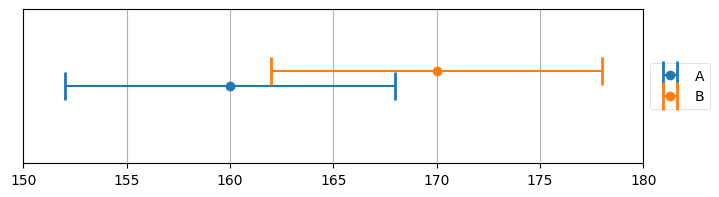

In [ ]:
import kf_book.book_plots as book_plots
from kf_book.book_plots import plot_errorbars
plot_errorbars([(160, 8, 'A'), (170, 8, 'B')], xlims=(150, 180))

简单说一下我如何生成这个图表。 我从子目录 `kf_book` 的book_plots模块中导入代码。生成这个图需要用到大量你可能不感兴趣的Python模板。我在书中经常使用这种方法。当运行单元格时， `plot_errorbars()` 会被调用，并将图表插入书中。

如果这是你第一次使用[Jupyter Notebook](http://jupyter.org/)，上面的代码处于一个 *单元格* 中。文本 "In [2]:" 将此标记为一个可输入的单元格，括号中的数字表示此单元格是第二个运行的。要运行单元格，请使用鼠标点击它使其获得焦点，然后按键盘上的CTRL+ENTER。你还可以更改单元格中的代码并重新运行它们，尝试将数值“160”、“170”和“8”更改为其它值并运行单元格，打印输出会随着你输入的内容而改变。

如果你想阅读plot_errobars的代码，要么在某个编辑器中打开它，要么创建一个新的单元格，然后键入函数名+两个问号，按下 Ctrl+Enter，浏览器将打开一个显示其源码的窗口。这是Jupyter Notebooks的一个特性，如果你只想查看函数的文档，请只用一个问号来完成相同的操作。

```Python

    plot_errorbars??
```
或
```Python
    plot_errorbars?
```

所以165磅看起来是一个更合理的估计，但还有更多我们可以利用的信息。唯一真实的重量可能位于A和B的误差条的交叉处。例如，秤B的读数为170磅，最大误差为8磅，那么161磅这样的一个估计是不可能正确的。同样道理，169磅的重量也是不可能的，因为秤A读数为160磅且最大误差为8磅。在本例中，唯一可能的重量在162-168磅的范围内。

这还不足以让我们得出一个更好的重量估计，但让我们来做出更多的“假设”。如果我们现在得知秤A的精度是B的三倍呢？在我们上面列出的5个选项中，选择A和B范围之外的数字仍然没有意义，所以我们不会去考虑那些。看起来选择A的读数作为估计值会更有说服力——毕竟我们知道它更精确一些，为什么不直接使用它来代替B？但相比单独使用A，B是否能改善我们的认知？

答案似乎有点反直觉：是可以的。首先，我们看到有一组相同的测量值，A=160和B=170，但不同的是A的误差为 $\pm$ 3 磅，B的误差为3倍，$\pm$ 9 磅。

In [ ]:
plot_errorbars??

Signature: plot_errorbars(bars, xlims, ylims=(-1, 1))
Source:   
def plot_errorbars(bars, xlims, ylims=(-1, 1)):
    """Plots a list of error bars with optional x and y limits.
    The list `bars` is a list of tuples (or any iterable) containing

    (mean value, error plus/minus, label)

    For example (160, 3, 'A') draws an error bar from 157 to 163, with the
    legend label 'A`)

    Parameters
    ----------

    bars : list
        list of tuples in form (mean, error +/-, label)

    x-lims : tuple
        tuple containing min and max values for x axis

    y-lims : tuple, optional
        tuple containing min and max values for y axis ( the default is (-1, 1))

    Example
    -------
    >>> plot_errorbars([(160, 3, 'A'), (170, 9, 'B')], xlims=(150, 180))
    """

    with figsize(y=2):
        i = 0.0
        for bar in bars:
            plt.errorbar([bar[0]], [i], xerr=[bar[1]], fmt='o', label=bar[2] , capthick=2, capsize=10)
            i += 0.2

        plt.ylim(*ylims)
  

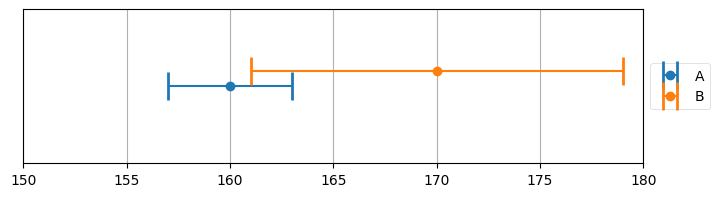

In [ ]:
plot_errorbars([(160, 3, 'A'), (170, 9, 'B')], xlims=(150, 180))

唯一可能的真实重量仍然落在A和B误差条的重叠处。这个重叠比秤A自身的误差要小。更重要的是，在这种情况下，我们看到重叠处不包括160磅或165磅。出于秤A比B更精确的考虑，我们单纯使用A测量，那么将给出160磅作为估计值。如果平均A和B，得到的是165磅。鉴于我们对秤精度的了解，这些重量估计都是不准确的。通过B测量的加入，我们可以给出一个介于161-163磅之间的估计值，这是被两个误差条的交叉点所限制。

再引入一些极限情形。假如我们知道秤A能够精确到1磅，也就是说，如果实际重量为170磅，那么它能够给出169、170或171磅的测量值。同时还知道秤B可以精确到9磅。我们在每一个秤上进行称重，得到A=160，B=170，这时候应该如何估计体重？让我们来看看图。

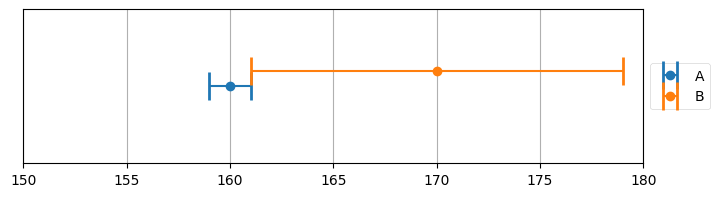

In [ ]:
plot_errorbars([(160, 1, 'A'), (170, 9, 'B')], xlims=(150, 180))

这里我们能看到唯一一个可能的重量是161磅。这是一个很重要的结论，有了两个相对不准确的传感器，我们能够推断出非常精确的结果。

**哪怕其中一个比另一个精度低，使用两个传感器也要比只用一个好**。我在本书的其余部分会详细讨论这个问题。无论一个信息的质量是多么差，我们都不会丢弃它。我们将开发公式与算法，允许我们使用所有可能的信息源来得出尽可能最优的估计。

然而我们已经偏离了我们的问题。没有哪个客户会购买好几个秤，而且最初我们假设所有秤的精度都是一样的。这种使用所有测量值而不论其精度的思想在后面会发挥很大的作用，所以不要忘记它。

如果我只有一个秤，但是我用它称了许多次呢？前面得出一个结论：如果我们有两个相同精度的秤，那应该平均它们的测量结果。那如果我用一个秤称10000次，又该如何做？我们已经说过，一个秤得到一个太大和太小的数字的可能性是差不多的。不难证明大量的重量测量数据，其平均值会非常接近实际重量。现在让我们编写一个模拟。我将会使用NumPy（[SciPy](https://scipy.org/) 生态中的一部分）来进行数值计算。

In [ ]:
import numpy as np
measurements = np.random.uniform(160, 170, size=10000)
mean = measurements.mean()
print(f'Average of measurements is {mean:.4f}')

Average of measurements is 164.9966


具体的数字取决于你的随机数生成器，不过它会非常接近165。

这个代码做了一个可能不太正确的假设——这个秤会像读出165一样读出160，然而真实重量还是165磅。真实的传感器会更多的得到接近真实值的读数，而偏离真实值的读数会越来越少，我们将会在高斯章节中详细介绍这点（译者注：这种现象叫做高斯分布）。而现在，我会继续使用 `numpy.random.normal()` 函数而不作更多的解释。它产生的值更多的会接近165磅，偏离的值会更少一点。所以暂且认为这是一个事实，即这种方法会类似一个真实的秤一样来产生带有噪声的测量值。

In [ ]:
mean = np.random.normal(165, 5, size=10000).mean()
print(f'Average of measurements is {mean:.4f}')

Average of measurements is 165.0220


结果依然非常接近165。

非常好，我们已经得到了一个传感器问题的答案！但它并不是一个非常实用的答案。没有人会有称自己体重一万次的耐心，甚至十几次都没有。

所以，让我们再玩一玩“假设”游戏。如果你每天称一次体重，然后依次得到170、161、169这几个读数，又会怎样？你是变重了，变轻了，还是这些都只是测量噪声？ 

我们无法轻易下定结论。第一个测量值是170，最后一次是169，只减少了1磅。但如果秤的精度只有10磅，那么就可以用噪声来解释了。可能我的体重的确增加了，也许第一天我的体重是165磅，然后第三天增加到了172磅。随着体重的增加也是有可能得到那些读数的。所以存在这种可能性，即使我的体重真的在增长，秤依然会告诉我体重减少了。来看看一个图表，我绘制了一些带有误差条的测量值，以及一些可能发生的体重增加/减少（用绿色的点线来表示）。

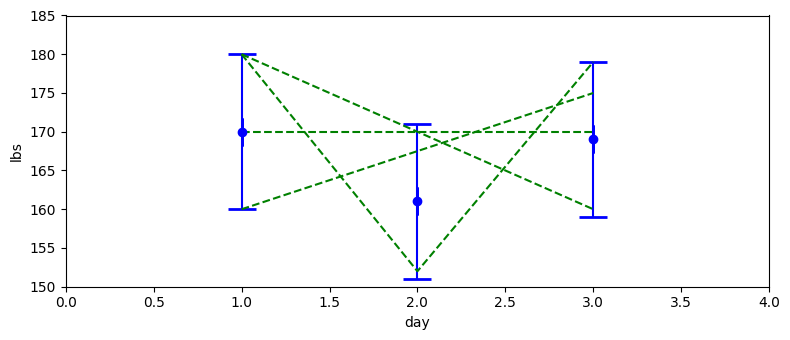

In [ ]:
import kf_book.gh_internal as gh
gh.plot_hypothesis1()

我们可以看到，这三个测量值可以表示出一个极端的体重变化范围。事实上，有着无数种数字组合，不过我不会放弃。提醒一下我们在讨论关于人类体重的测量，对于一个人类来说，第一天180磅然后第三天变成160磅，又或者一天减轻30磅，这种事情是不可能的（假设这个人没有发生截肢或者其它创伤）。

我们所测量的实体，其行为会影响到我们对于测量值的解释。如果我们每天对一块石头称重，那么会把所有误差归结为噪声。而如果称重对象是一个家用的接纳雨水的蓄水池，那我们可能会相信这些重量变化是真实的。
 
假设我再来称一组体重，得到如下测量值：169、170、169、171、170、171、169、170、169、170。直觉告诉你发生了什么？例如，有可能你每天增加了1磅重量，然而那些有噪声的测量值却看起来像是你的体重并没有太大变化。同样也有可能是你每天变轻1磅然后得到了同样的读数。但这些有可能吗？掷一个硬币连续10次正面的可能性有多大？不太可能。看起来我的体重可能保持稳定，但不能仅仅根据这些读数就可以证明这点。下面的图表中，我绘制了一些带有误差条的测量值和表示可能的真实体重的绿色虚线。这条虚线并不代表这个问题的“正确”答案，只是一个比较合理并能用测量值解释的答案。

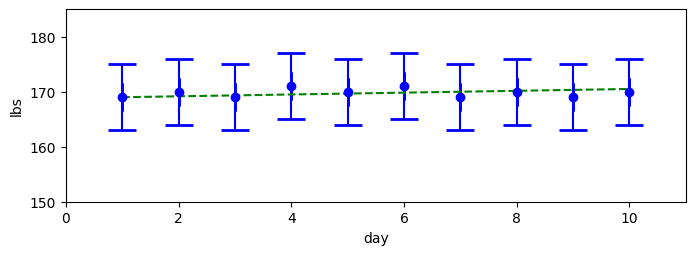

In [ ]:
gh.plot_hypothesis2()

另一个假设：如果读数为158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0? ，会怎样？让我们看看这个图表，然后解答一些问题。

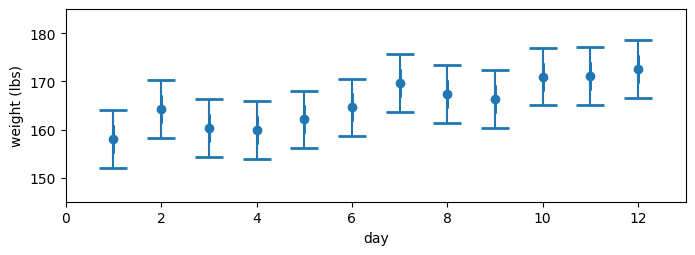

In [ ]:
gh.plot_hypothesis3()

是否它“看起来”像是我的体重减少了而这些数据只不过带有噪声而已？不对。那难道是我的体重没有变化？还是不对。随着时间的推移这些数据呈现上升的趋势，虽不均匀，但绝对是在上升。虽然我们不能确定，但那的确看起来像是体重上升，非常明显。让我们来用更多的图表来测试这个假设，相对表格而言图表更容易让我们关注数据。

让我们来看看两个假设。首先，假定体重没有变化。为了得到这个数字需要平均测量值，让我们来看一下。

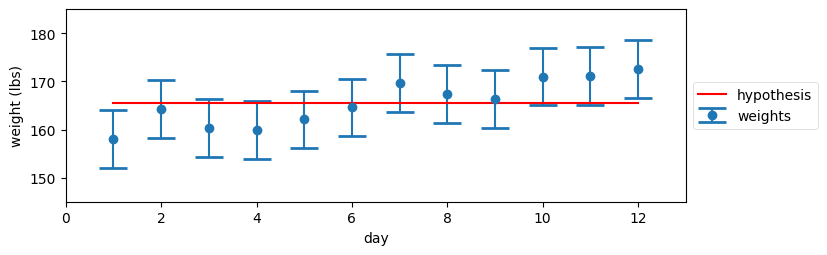

In [ ]:
gh.plot_hypothesis4()

这看起来不太有说服力。实际可以看到，我们无法画出一条位于所有误差条内的水平线。

那么现在来假设我们的体重增加了。增加了多少？我不清楚，但是NumPy知道！我们想画一条看起来“差不多”是正确的线穿过测量值，NumPy有函数可以根据一个称为“最小二乘拟合”的规则来实现这一点。我们不必太关心计算细节（我用的是[polyfit()](https://docs.scipy.org/doc/numpy/reference/generated/numpy.polyfit.html)，如果你感兴趣的话），只绘制出结果即可。

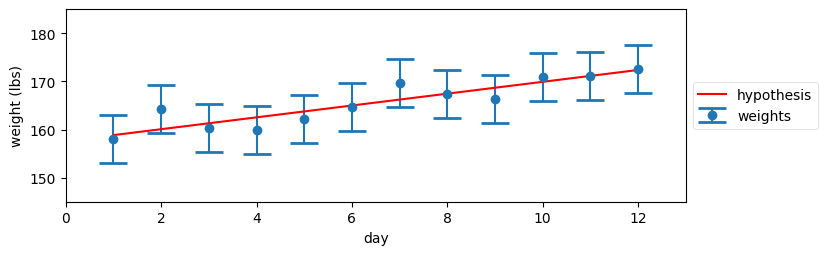

In [ ]:
gh.plot_hypothesis5()

至少在我看来，这个结果好多了。注意，现在的假设已经非常接近每一个测量值了，而在前面的图表中，通常都离测量值相当远。从这个结果来看，我似乎更可能是增重了，而不是没有变化。不过我真的变胖了13磅吗？没有谁知道，似乎不太可能回答这个问题。

“但如果这不可能呢？”一个同事说道。

让我们来做一些疯狂的尝试。假如我知道我每天增重1磅，假设现在知道这是大致正确，而不用管我是怎么知道的。也许是我一天吃6000卡路里的食物而导致的体重增加，又或者是另一种方法。这只是一个思想实验，细节不重要。让我们来看看是否可以利用这些信息，如果它是可用的。

第一个测量值是158。我们无法得知这是否有什么异常，所以接受这个结果作为估计。如果我们今天的体重是158磅，那明天会是多少？嗯，我们认为我们的体重正在以1磅/天的速度增长，所以预测是159磅，就像这样：

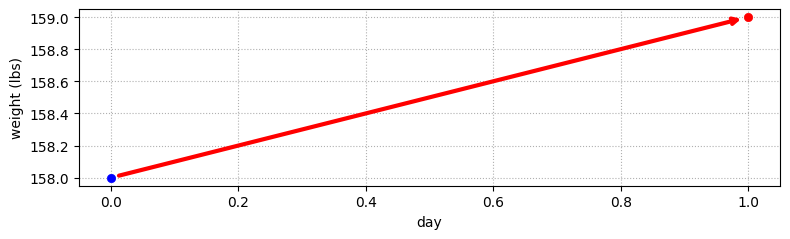

In [ ]:
gh.plot_estimate_chart_1()

好吧，不过这有什么好处？当然，我们能够假设1磅/天的增长是精确的，并预测未来十天的体重，但如果我们不把它和秤的读数结合起来，还要秤干嘛？所以让我们看下下一个测量：再次站到了秤上，它显示164.2磅。

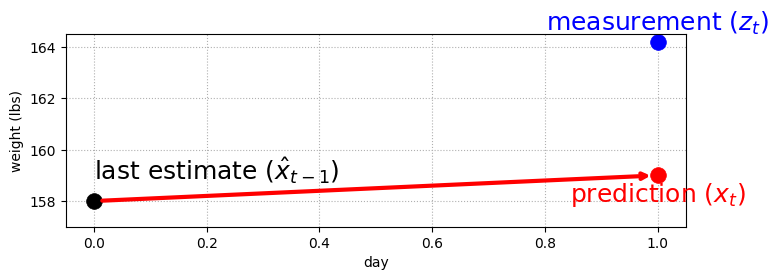

In [ ]:
gh.plot_estimate_chart_2()

有麻烦了，我们的预测与测量结果不匹配。但这不正如我们所期望的，对吧？如果预测总是和测量完全一样，那它将无法给滤波器带来任何额外的信息。当然如果预测是完美的，那就完全没必要再去测量了。

> **整本书的关键核心思想在下一段，请仔细阅读！**

所以我们该怎么办？如果我们只从测量结果中得出估计值，那么预测对结果不会有任何影响。但如果只使用预测，那么测量值将被无视。可以的话，我们需要采取某种方式**将预测和测量混合到一起**（已经把重点划出来了）。

混合两个值——这听起来有点像前面那个使用两个秤的问题。使用与其相同的理由，我们可以看到唯一有意义的做法是在预测和测量值之间选择一个数字。例如，165和157作为估计是不可能的。我们的估计应该在159（预测）和164.2（测量）之间。

这再次显得如此重要，即我们认为，当存在两个带有误差的值时，我们应该选择在两个数据之间的范围选择一个值作为估计。这些值如何产生的倒是无所谓。这章开头时我们有两个测量值，而现在有一个测量值和一个估计值。在这两种情况下，推理和数学都是相同的。我们*从未*扔掉任何信息，我的意思是，我见过太多商业软件会抛弃掉那些带有噪声的数据。别这么做！我们对体重增加的预测可能不是很准确，但只要有一些信息，我们就应该使用它。

我必须坚持让你停下来并好好思考一下这个。我所做的只是用一个基于人类生理的不精确的体重预测来代替一个不精确的秤。但它依然是数据。数学公式不知道这个数据是来源于一个秤还是一个预测。我们有了两块带有一定量噪声的数据，然后想将它们联合起来。本书中的其余部分将会建立一些相当复杂的数学公式来执行这个计算，但公式不关心数据来源，它只会基于数据及其精度来做一些计算。

估计值应该位于测量值和预测值中间吗？可能是，但通常看起来我们应该知道相比测量值，预测值的精度是更高还是更低。预测的精度和秤的精度大概率会是不一样的。回想一下前面当秤A比秤B更精确时，我们是怎么做的——会让答案比起B来更接近A一些。来看看一个图表。

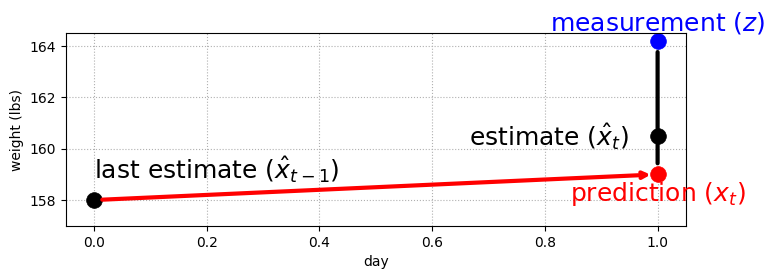

In [ ]:
gh.plot_estimate_chart_3()

现在让我们试着随机选择一个数字来划分我们的估计：$\frac{4}{10}$。那么估计值将会有十分之四来源于测量值，剩余的来源于预测值。换而言之，在这里我们表达了一个信任度：预测值比起测量值更可能正确。于是有如下计算：

$$\mathtt{estimate} = \mathtt{prediction} + \frac{4}{10}(\mathtt{measurement} - \mathtt{prediction})$$

测量与预测之间的差值称之为*残差(residual)* ，即上面图表中那条黑色的竖线。作为一个滤波器输出与测量值之间误差的精确计算，以后它会成为我们所使用的一个重要的值。更小的残差意味着更好的性能。

让我们来写代码来测试一下上面的一系列体重数据，看看结果。我们必须考虑到另一个因素，体重增长的单位是磅/时间，所以原则上我们需要增加一个时间步长$t$，并设置其为1（天）。

我以160磅作为真实起始体重，体重增长为一天1磅生成了体重数据。也就是说，第一天真实体重为160磅（第0天），然后第二天（称重的第一天）真实体重为161磅，依此推算。

原本我们需要推测出一个初始体重，但现在讨论初始化策略过早了，所以我假设它为160磅。

In [ ]:
from kf_book.book_plots import figsize
import matplotlib.pyplot as plt

weights = [158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 
           169.6, 167.4, 166.4, 171.0, 171.2, 172.6]

time_step = 1.0  # day
scale_factor = 4.0/10

def predict_using_gain_guess(estimated_weight, gain_rate, do_print=False):     
    # storage for the filtered results
    estimates, predictions = [estimated_weight], []

    # most filter literature uses 'z' for measurements
    for z in weights: 
        # predict new position
        predicted_weight = estimated_weight + gain_rate * time_step

        # update filter 
        estimated_weight = predicted_weight + scale_factor * (z - predicted_weight)

        # save and log
        estimates.append(estimated_weight)
        predictions.append(predicted_weight)
        if do_print:
            gh.print_results(estimates, predicted_weight, estimated_weight)

    return estimates, predictions

initial_estimate = 160.
estimates, predictions = predict_using_gain_guess(
    estimated_weight=initial_estimate, gain_rate=1, do_print=True)     

previous estimate: 160.00, prediction: 161.00, estimate 159.80
previous estimate: 159.80, prediction: 160.80, estimate 162.16
previous estimate: 162.16, prediction: 163.16, estimate 162.02
previous estimate: 162.02, prediction: 163.02, estimate 161.77
previous estimate: 161.77, prediction: 162.77, estimate 162.50
previous estimate: 162.50, prediction: 163.50, estimate 163.94
previous estimate: 163.94, prediction: 164.94, estimate 166.80
previous estimate: 166.80, prediction: 167.80, estimate 167.64
previous estimate: 167.64, prediction: 168.64, estimate 167.75
previous estimate: 167.75, prediction: 168.75, estimate 169.65
previous estimate: 169.65, prediction: 170.65, estimate 170.87
previous estimate: 170.87, prediction: 171.87, estimate 172.16


[158.0,
 164.2,
 160.3,
 159.9,
 162.1,
 164.6,
 169.6,
 167.4,
 166.4,
 171.0,
 171.2,
 172.6]

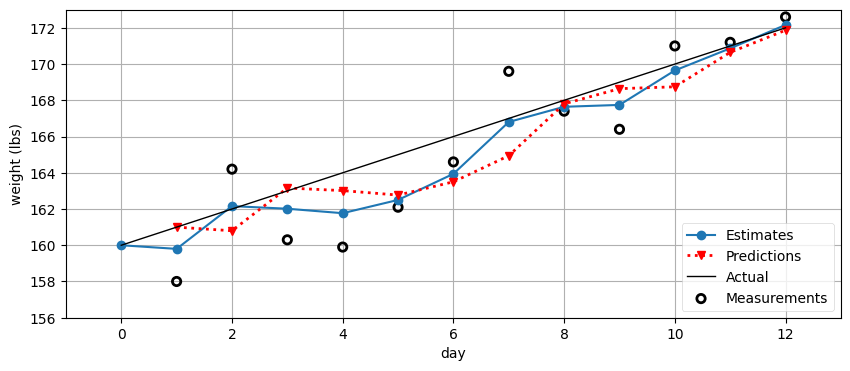

In [ ]:
# plot results
book_plots.set_figsize(10)
gh.plot_gh_results(weights, estimates, predictions, [160, 172])
weights

相当棒！这里有很多数据，我们来讨论一下怎么解释它们。蓝色粗线显示的是滤波器的估计，它以160磅作为初始值开始于第0天。红色虚线显示了根据前一天体重进行预测的预测值。所以，在第一天时前一天的值为160磅，体重增长为1磅，所以第一个预测是161磅。第一天的估计介于预测与测量值之间，为159.8磅。图表下方打印出来的是每一天的上一次体重（估计），体重预测和体重的新估计。最后，细黑线显示了这个人的真实体重增长。

过一遍每一天的数据，确保你能够理解每一步中的预测和估计是如何形成的。做一下笔记，这些估计值是如何落在测量值与预测值之间的。

估计值不是一条直线，但它们要比测量值更直一些，并且多多少少更接近我们创造的真实趋势。还有，它似乎随着时间增长而变得更好了。

滤波器的结果可能会让你觉得很傻。数据当然会看起来很好，因为我们假设了一个推论：体重增长大约为1磅/天！让我们看看如果初始推测是不好的，滤波器会如何表现。让我们做一个预测，体重将会按1磅/天的速度降低：

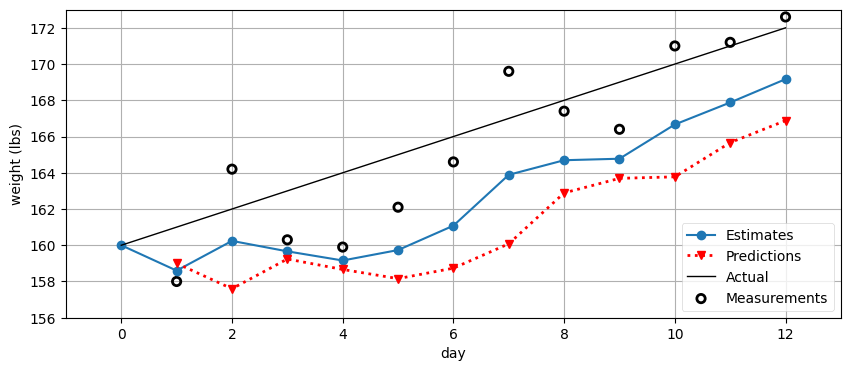

In [ ]:
e, p = predict_using_gain_guess(initial_estimate, -1.)
gh.plot_gh_results(weights, e, p, [160, 172])

这不怎么令人印象深刻，估计会迅速偏离测量值。显然一个需要我们正确推测出改变率的滤波器是不怎么有效的。即使我们的初始推测是准确的，滤波器会和改变率一样快让人失望。如果我停止过度干涉，滤波器将会极难调整那个改变。注意它是可以调节的！即使我们告诉它每天减少1磅，估计依然在增长，只是它调整的速度不够。

但是，“假设。。。会怎样”，假设我们从现有的测量值和估计值中计算出体重增长率，而不是像开始时推测其为1磅（不管怎样），会发生什么。第一天我们的体重估计是：

$$
(160 + 1) + \frac{4}{10}(158-161) = 159.8
$$

第二天的测量值为164.2，意味着体重增长为4.4磅（164.2 - 159.8 = 4.4）而不是1磅。我们能以某种方式来使用这个信息吗？看起来貌似有点道理，毕竟，体重测量自身是基于真实世界中我们体重的测量，所以还是有有用的信息。我们对于体重增长的估计未必完美，但它无疑比我们单纯地猜测体重增长为1磅要好得多。数据要比猜测更好，即使它带有噪声。

人们确实会在这一点上产生犹豫，所以确保你能保持意见一致，两个带有噪声的测量值给我们暗示了体重的增长或减少。如果测量值不精确，那这个估计会变得很不精确，但这个计算中依然包含了信息。想象使用一个精度为1磅的秤给一头奶牛称重，它显示奶牛增重了10磅。根据不同的误差，奶牛可能实际增重了8-12磅，但我们知道了它体重增加了，并且大概是多少。这就是信息。我们应该如何对待信息？永远不要丢弃它！

回到原来的主题上。我应该设置新增长率（new gain）为4.4磅/天吗？昨天我们认为体重增长为1磅，今天又认为其为4.4磅。我们有两个数字，想通过某种方式把它们结合起来。嗯，听起来又是同样的问题。让我们使用同样的工具，并且是我们目前拥有的唯一工具——两者之间按一定比例取一个值。这次我会任意选择另一个数字，$\frac{1}{3}$。这个方程和体重估计的那个是一样的，除了因为这是一个速率（增长/天）所以必须加入时间：

$$
\text{new gain} = \text{old gain} + \frac{1}{3}\frac{\text{measurement - predicted weight}}{1 \text{ day}}
$$

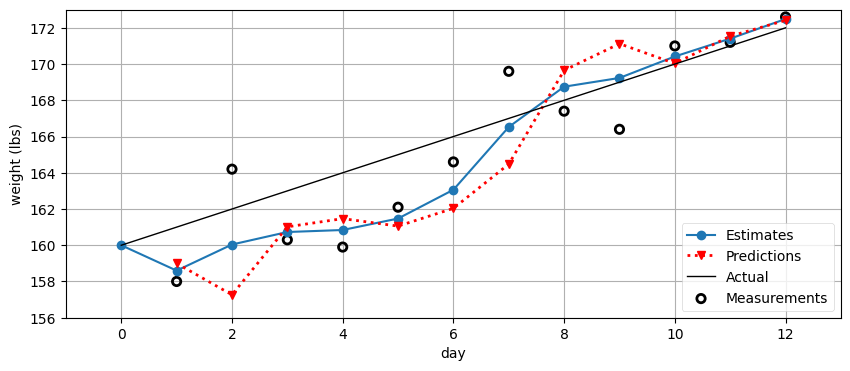

In [ ]:
weight = 160.  # 初步猜测
gain_rate = -1.0  # 初步猜测

time_step = 1.
weight_scale = 4./10
gain_scale = 1./3
estimates = [weight]
predictions = []

for z in weights:
    # 预测
    weight = weight + gain_rate*time_step
    gain_rate = gain_rate
    predictions.append(weight)
    
    # 更新    
    residual = z - weight
    
    gain_rate = gain_rate + gain_scale   * (residual/time_step)
    weight    = weight    + weight_scale * residual
  
    estimates.append(weight)

gh.plot_gh_results(weights, estimates, predictions, [160, 172])

我认为这开始看起来比较不错了。因为那可怜的初始推测（1磅/天）让滤波器花了几天时间才能准确预测体重，但一旦达到，它将会精确跟踪体重。我们没有使用任何方法来选择比例参数 $\frac{4}{10}$ 和 $\frac{1}{3}$ （事实上这个选择对于这个问题来说是比较差的），但除此之外，所有公式都遵循非常合理的假设。再提醒一下，如果你想看到这个图表一步步画出来，可以将 `time_step` 这个参数的值改为一个更大的值并重新运行单元格。

我们继续前还有最后一点要说明。在预测步骤中，我写了一行
```python
gain_rate = gain_rate
``` 
这显然是没有效果的，可以删除掉。我写下这个是为了强调在预测步骤中你需要预测所有变量的下一个值，包括 `weight` 和 `gain_rate`。这很快会变得有意义。这个例子中我们假设实际增长（率）是没有变化的，但我们推广这个算法时将会移除这个假设。

## g-h滤波器

这个算法被称为 [g-h滤波器](https://en.wikipedia.org/wiki/Alpha_beta_filter) 或 $\alpha$-$\beta$ 滤波器。 $g$ 和 $h$ 分别指在例子中我们使用的两个比例参数。$g$ 是用于测量值的比例（例子中的体重）， $h$ 是测量值随着时间改变的比例（例子中的磅/天）。 $\alpha$ 和 $\beta$ 只是这两个参数的不同名字而已。

这个滤波器是大量滤波器的基础，包括卡尔曼滤波器。换句话说，卡尔曼滤波器是g-h滤波器的某种形式，我将会在本书后面证明这点。还有你可能听说过的最小二乘滤波器和没听说过的Benedict-Bordner滤波器也是。这每一种滤波器都有不同的方式来设定 $g$ 和 $h$的值，但在其他方便这些算法都是一样的。例如，Benedict-Bordner滤波器给 $g$ 和 $h$分配一个常量，并将其值约束在一定范围内。其它滤波器如卡尔曼会在每一个时间步骤里动态修改 $g$ 和 $h$ 。

**让我重复一下重点，因为它们非常重要**。如果理解不了这些你将无法理解本书的剩余部分。如果你真的理解了它们，那本书的剩余部分，即各种有关 $g$ 和 $h$ 的“假设”问题的数学阐述，将会很自然地向你呈现。数学公式可能看起来大不相同，但算法将是完全一致的。

* 多个数据点比单一数据点更精确，所以不要丢掉任何东西无论它多么不精确。
* 始终在两个数据点之间的某个位置选择一个数字，以得到一个更精确的估计。
* 基于当前估计及我们认为它将会改变多少，来预测下一个测量值和变化率。
* 然后应该在预测和下一次测量值之间选择新的估计，比例取决于两者的精确度。

让我们来看看这个算法的可视化描述。

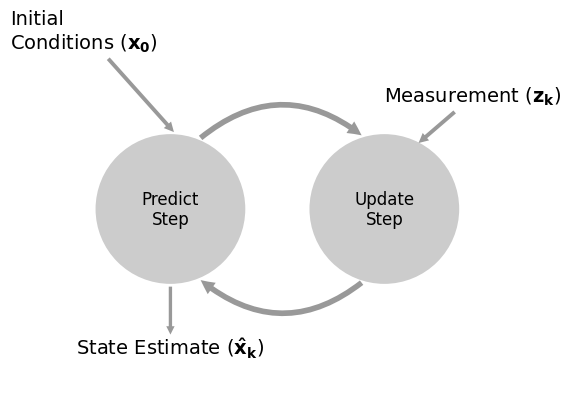

In [ ]:
book_plots.predict_update_chart()

让我来介绍更多的专业术语。*系统（system）* 是我们要估计的对象，这章里系统便是我们所称重的任何东西，有些教科书里称它为 *plant*。这个术语来源于控制系统理论。 https://en.wikipedia.org/wiki/Plant_(control_theory)

系统的 *状态（state）* 是我们感兴趣的系统其当前配置或者数值。我们只对重量读数感兴趣，如果我在秤上放了个100kg重的物体，其状态是100kg。我们定义状态为与我们相关的东西。秤的颜色与我们无关，因此不在状态中包含这些值。生产商的QA（质量保证）工程师可能会在状态中包含颜色，以便可以跟踪和控制生产过程。 

*测量（measurement，也称之为观测）* 是系统的测量值。测量可能不准确，所以它可能与状态值不一样。

*状态估计（state estimate）* 是我们的滤波器对状态的估计。例如，对于100kg的重量，由于传感器误差我们的估计可能为99.327kg。这个通常被简写为*估计*，我在这一章中就是这么做的。

或者说，状态可以被理解为系统的实际值，但这个值通常对我们是*不可见*的。如果我站到秤上，你会得到一个*测量值*。我们称其为*可观测*，因为你可以直接看到这个测量结果。相比之下，你永远不能直接得到我的真实体重，只能去测量它。

这种*隐藏*和*可观测*的语言很重要。任何估计问题都是由通过可观测的测量值来产生对隐藏状态的估计而组成的。如果阅读一篇文献，这些术语会在定义问题时用到，所以你要适应它们。

我们使用*过程模型（process model）*来对一个系统进行数学建模。这一章中的过程模型为假设我今天的体重是昨天的体重加上最后一天的体重增长。过程模型并不对传感器建模或者以其它方式来解释。另一个例子是汽车的过程模型，其过程模型可以是“距离等于速度乘以时间”。这个模型并不完美，因为汽车的速度可以在非零时间内变化，轮胎可以在路上打滑，等等。这个模型里的误差就是*系统误差*或者说*过程误差*，我们从未确切知道这个值。如果知道，我们可以改进模型，使其误差为0.有些教科书使用*plant model*和*plant error*，你还可能见到*系统模型（system model）*。这些都是表达一样的意思。

预测步骤称为*系统传播（system propagation）*。它使用*过程模型*来形成一个新的*状态估计*。由于*过程误差*的存在这个估计是不完美的。假设我们随着时间的推移跟踪数据，我们可以说我们将状态*传播*到了未来。有些教科书称之为*进化（evolution）*。

更新步骤称为*测量更新（measurement update）*。系统传播和测量更新的一次迭代称为一个*epoch*。 

现在让我们来探索一些不同领域的问题，以便更好理解这个算法。考虑一个尝试跟踪轨道上火车的问题。轨道将火车限定在一个非常特定的区域。此外，火车又大又慢，需要花上许多分钟才能减速或者显著加速。因此如果我知道火车t时刻位于23km处并以18km/小时的速度行驶，我可以极其自信地预测它在t+1秒时的位置。为什么这很重要？假设我们只能以$\pm$ 250米的精度测量它的位置，而火车以每小时18km即每秒5米的速度行驶，t+1秒时火车将到达23.005km处，但是测量范围可能在22.755-23.255km之间。所以如果下一个测量结果显示位置为23.4，那我们知道这一定是不准确的。即使在T时刻，工程师猛踩刹车，火车仍将接近23.005km，因为它在1秒内无法减速过快。如果要针对这个问题进行设计（将在本章中进一步介绍！），我们将会设计一个预测的权重远大于测量的滤波器。

现在考虑一个跟踪投掷的球的问题。我们知道在重力场中，一个飞行的物体会在真空中进行抛物线运动。但是在地球上抛掷的球会受到空气阻力的影响，所以它不会以完美的抛物线运动。棒球投手在投出曲线球时利用了这一点。假设我们正在用计算机视觉跟踪体育场内的球——这正是我工作在做的。计算机视觉跟踪的精度可能不高，但假设球在做抛物线运动来预测其未来位置也不会太精确。在这种情况下，我们可能会设计一个测量和预测权重大致相等的滤波器。

再来考虑一下在飓风中追踪氦气派对气球。除了在非常短的时间尺度内（例如我们知道气球不能在1秒内飞行10英里），我们没有一个合理的模型来预测气球的行为。在这种情况下，我们设计的滤波器，会更多地强调测量而不是预测。

这本书的大部分都在致力于用数学方式来表达最后三个列子中关注点，然后找到一个最佳解决方案（在某种数学意义上的）。而在这一章中，我们只会以一种更直观而不是最优的方式为$g$和$h$分配不同的值。但其基本思想是将一些不精确的测量值和系统行为模型混合起来，得到一个滤波后的估计值，这个估计值比任何一个信息源本身都要好。

我们将其表示为一种算法:

**初始化**

    1. 滤波器状态初始化
    2. 状态置信度初始化

**预测**

    1. 使用系统行为来预测下一个时间步骤的状态
    2. 根据预测的不确定性来调整置信度
    
**更新**

    1. 得到一个测量值，并根据其精度来确定置信度
    2. 计算状态估计与测量值的残差
    3. 根据残差来得到新的估计值
    
我们将在整本书中使用这一相同的算法，尽管它们经过了一定的修改。 

## 符号

我将开始介绍文献中使用的符号和变量名，其中有一些在上面的图表中已经用到了。测量值通常用$z$表示，这就是这本书中会用到的（有一些资料中使用$y$）。下标k表示时间步骤，所以$z_k$是指当前时间步骤的数据。字体加粗表示矢量或矩阵。到目前为止，我们只考虑有一个传感器的情况所以只有一个传感器测量值，但一般来说，我们可能会有n个传感器和n个测量。$\mathbf{x}$表示状态，粗体表示它是一个向量。对于我们的称重例子来说，它表示初始重量和初始重量增加率，如下所示：

$$\mathbf{x} = \begin{bmatrix}x \\ \dot{x}\end{bmatrix}$$

这里我在x上加一个点，即牛顿符号（译者[Wang Weiyun](https://github.com/loveuav)注：对应的是莱布尼茨符号）来表示速度。更准确地说，点意味着x对时间的导数，当然是速度。对于62kg的体重且增长率为0.3kg/天，我们有

$$\mathbf{x} = \begin{bmatrix}62 \\ 0.3\end{bmatrix}$$

所以，这个算法很简单。状态由初始估计值$\mathbf{x_0}$初始化，然后进入一个循环。从时间（步骤）$k-1$时的状态值来预测时间（步骤）$k$的状态，然后我们得到测量值 $z_k$，在测量值和预测值之间选择一个中间点，得到估计 $\mathbf{x}_k$。

## Exercise: Write Generic Algorithm

在上面的例子中，我们已经用编码解决我们在本章中讨论过的称重问题。例如，变量名为“weight_scale”，“gain”等。我这样做是为了使算法易于理解，您可以很容易地看懂我们在每个步骤做了什么。但是，这是针对一个特定问题编写的代码，但是算法对于任何问题都是相同的。因此，让我们重写一个通用的代码，让它处理任何问题。我们定义一个这样的方法：

```python
def g_h_filter(data, x0, dx, g, h, dt):
    """
    Performs g-h filter on 1 state variable with a fixed g and h.

    'data' contains the data to be filtered.
    'x0' is the initial value for our state variable
    'dx' is the initial change rate for our state variable
    'g' is the g-h's g scale factor
    'h' is the g-h's h scale factor
    'dt' is the length of the time step 
    """
```

用NumPy数组作为返回值，而不使用列表。通过传递与以前相同的重量数据来测试它，绘制结果，并直观地确定它是否有效。

In [ ]:
from kf_book.gh_internal import plot_g_h_results
def g_h_filter(data, x0, dx, g, h, dt):
    pass #  your solution here

# uncomment to run the filter and plot the results
#book_plots.plot_track([0, 11], [160, 172], label='Actual weight')
#data = g_h_filter(data=weights, x0=160., dx=1., g=6./10, h=2./3, dt=1.)
#plot_g_h_results(weights, data)

### 答案和讨论

[158.0, 164.2, 160.3, 159.9, 162.1, 164.6, 169.6, 167.4, 166.4, 171.0, 171.2, 172.6]
[159.2   161.8   162.1   160.78  160.985 163.311 168.1   169.696
 168.204 169.164 170.892 172.629]


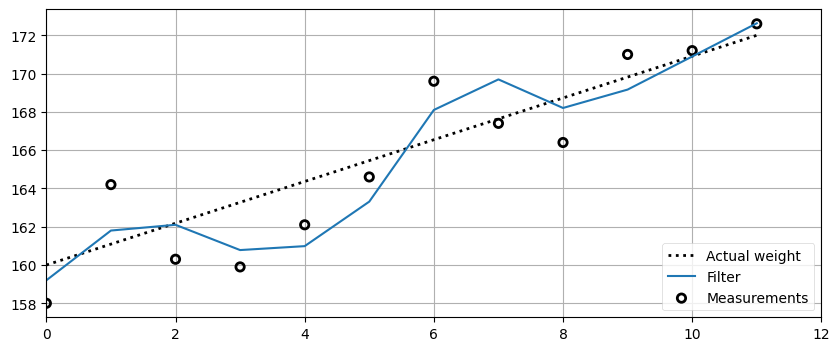

In [ ]:
import matplotlib.pylab as pylab

def g_h_filter(data, x0, dx, g, h, dt=1.):
    x_est = x0
    results = []
    for z in data:
        # prediction step
        x_pred = x_est + (dx*dt)
        dx = dx

        # update step
        residual = z - x_pred
        dx = dx + h * (residual) / dt
        x_est = x_pred + g * residual
        results.append(x_est)
    return np.array(results)

book_plots.plot_track([0, 11], [160, 172], label='Actual weight')
data = g_h_filter(data=weights, x0=160., dx=1., g=6./10, h=2./3, dt=1.)
plot_g_h_results(weights, data)
print(weights)
print(data)

这应该是很简单的。我只是将代码中的体重，增长率等变量名称替换成了定义的`x0`，`dx`等。其他的没有变化。

## $g$和$h$的选择

g-h滤波器不是一个单独滤波器，它是一系列过滤器的总称。 Eli Brookner在《Tracking and Kalman Filtering Made Easy》一书中列举了11个滤波器，我相信应该更多。不仅如此，每种类型的滤波器都有许多的子类型。每个滤波器的区别在于如何选择$g$和$h$。所以我在这里没有“一刀切”的建议。有些滤波器将$g$和$h$设置为常量，其他过滤波器则动态地改变它们。卡尔曼滤波器就是在每一个时间步长中都动态地改变它们。有的滤波器允许$g$和$h$取一个范围内的任意值，还有的滤波器通过函数约束使一个变量依赖于另一个
$f(\dot{}), \mbox{where }g = f(h)$。

本书的主题不是整个g-h过滤器系列; 更重要的是，我们对还没有提到的贝叶斯滤波器更感兴趣。 因此，我不会深入讨论$g$和$h$的选择方式。《Tracking and Kalman Filtering Made Easy》是学习这部分内容的一个很好的资源。如果这让你感到困惑，请认识到卡尔曼滤波器的典型方法是根本不使用g和h。卡尔曼滤波器是一个g-h滤波器，因为它在数学上减少了这种算法。当我们设计卡尔曼滤波器时，我们使用的设计标准可以在数学上减少到g和h，但卡尔曼滤波器形式通常是一种更有效的思考问题的方法。不要担心，如果现在不太清楚，一旦我们开始介绍卡尔曼滤波器理论你就会清楚。

值得注意的是$g$和$g$的变化会对结果产生怎样的影响，因此我们将通过一些例子来研究它。这将使我们深入了解此类过滤器的优势和局限性，并帮助我们了解更复杂的卡尔曼滤波器的特点。

## 创建测量函数

现在让我们编写一个为我们生成噪声数据的函数。在本书中，我将含有噪声信号模拟为信号加上[白噪声](https://en.wikipedia.org/wiki/White_noise)。你可能还没有完全理解白噪声的定义。 实质上，可以将其视为随机变化的数据的信号，时而高和时而低，不存在特定的模式。我们认为它是一个连续的均值为零和方差固定的不相关的随机变量。如果你现在还不理解这一点，在学习后面的*高斯*这一章节后你会理解的。如果您对统计理论不了解，则可能无法完成此练习。如果是这样，你可以直接看下面的代码和讨论。

`numpy.random.randn()`可以生成白噪声。我们需要一个函数，它通过起始值、每一步的变化量、步数和要添加的噪声量来调用。它应该返回一个数据列表。通过创建30个点的数据进行测试，使用`g_h_filter()`进行滤波，使用`plot_g_h_results()`绘制结果。

In [ ]:
# your code here

### 答案

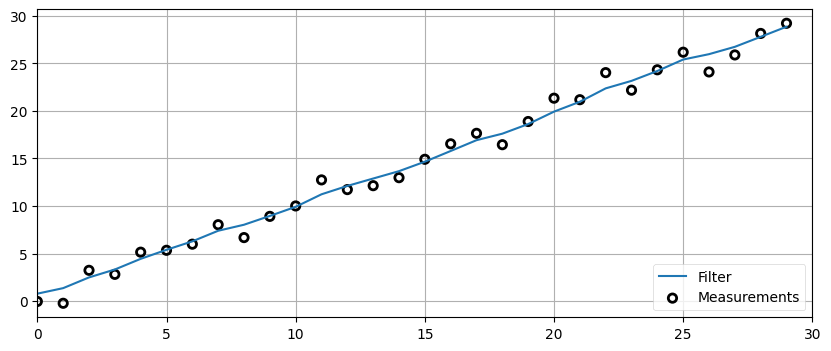

In [ ]:
from numpy.random import randn
def gen_data(x0, dx, count, noise_factor):
    return [x0 + dx*i + randn()*noise_factor for i in range(count)]

measurements = gen_data(0, 1, 30, 1)
data = g_h_filter(data=measurements, x0=0., dx=1., dt=1., g=.2, h=0.02)
plot_g_h_results(measurements, data)

### 讨论

函数`randn()`的返回值是以0为中心的随机数，它可能大于零，也可能小于零。它有一个*标准差*——如果您不知道什么叫标准差，请不要担心。我用`randn()`绘制了3000个点，你可以看到这些值以零为中心波动，大多数值的范围在-1到1，但偶尔它们也会超出很多。

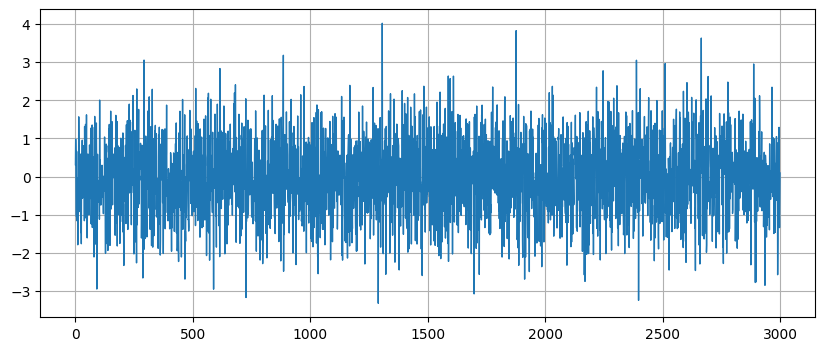

In [ ]:
plt.plot([randn() for _ in range(3000)], lw=1);

## 实验：糟糕的初始条件

我们再编写一个使用`gen_data`和`g_h_filter`来对100个数据点过滤的代码，这些数据点从5开始，变化率为2，噪声比例因子为10，g=0.2，h=0.02。但是把x的初始预测值设置为100。

In [ ]:
# your code here

### 答案和讨论

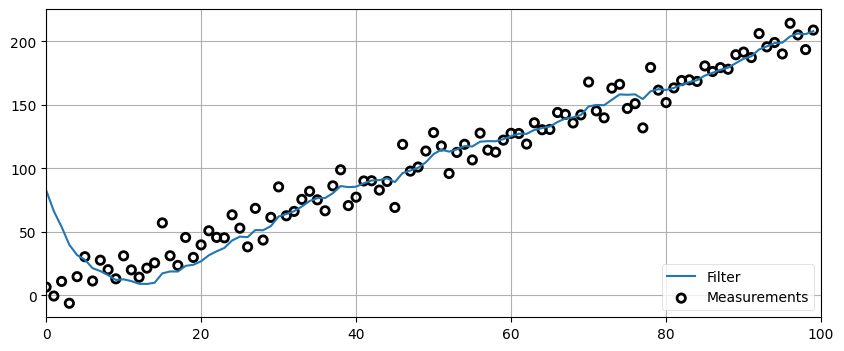

In [ ]:
zs = gen_data(x0=5., dx=2., count=100, noise_factor=10)
data = g_h_filter(data=zs, x0=100., dx=2., dt=1., g=0.2, h=0.02)
plot_g_h_results(measurements=zs, filtered_data=data)

由于初始的预测值为100是十分错误，所以滤波器的估计值离测量数据十分远。在估计值逐渐接近测量数据之前，您可以看到“rings”。 “ringing”意味着信号以类似正弦的形式形成超调和负调。这是滤波器使用中非常常见的现象，滤波器设计中的许多工作都致力于最小化“ringing”。我们还没有准备解决这个问题，但我想先向你展示这一现象。

## 实验：更强的噪音

重新运行相同的测试代码，但这次使用的噪声系数设为100。将初始条件从100改回5来消除初始条件造成的“ring”。

In [ ]:
# your code here

### 答案和讨论

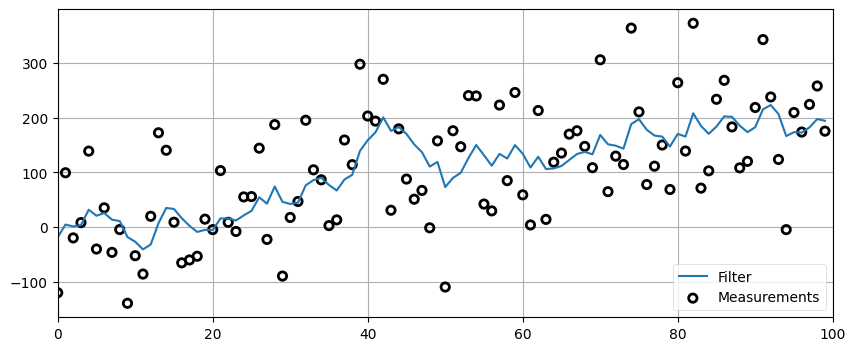

In [ ]:
zs = gen_data(x0=5., dx=2., count=100, noise_factor=100)
data = g_h_filter(data=zs, x0=5., dx=2., g=0.2, h=0.02)
plot_g_h_results(measurements=zs, filtered_data=data)

这对我来说并不是那么完美。我们可以看到，也许滤波信号的变化小于噪声信号，但它远不是直线。如果我们只绘制过滤后的结果，没有人能猜出来这是从5开始并以每个时间步长增加2的原始信号。 虽然在某些位置，滤波器似乎可以降低噪声，但在其他地方，它似乎仍然会出现超调和负调。

在这一点上，我们无法真正判断这个滤波器的好坏。毕竟我们增加了**很多**噪音，但也许这已经是很不错的一个滤波器了。其实，在后面的章节我们会发现可以有做得更好的滤波器。

## 实验: 加速度的影响

写一个新的数据生成函数，为每个数据点添加一个恒定的加速因子。 换句话说，增加dx来计算每个数据点时，速度（dx）也在不断增加。 将噪音设置为0，$g=0.2$和$h = 0.02$，并使用`plot_g_h_results`或你自己的方法绘制结果。分别使用不同的加速度和步长实验。尝试解释你所看到的。

In [ ]:
# your code here

### 答案和讨论

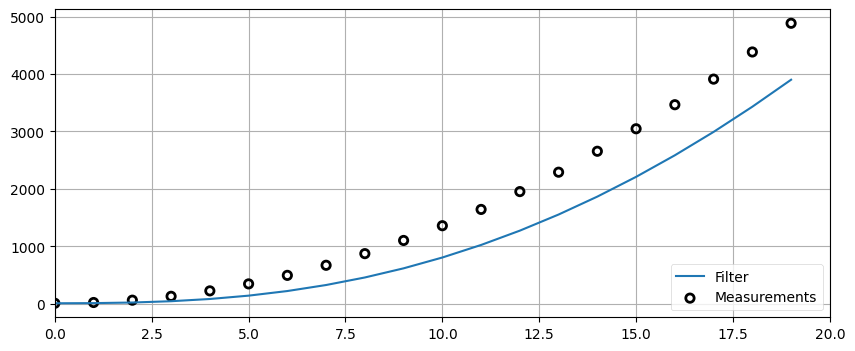

In [ ]:
def gen_data(x0, dx, count, noise_factor, accel=0.):
    zs = []
    for i in range(count):
        zs.append(x0 + accel * (i**2) / 2 + dx*i + randn()*noise_factor)
        dx += accel
    return zs
   
predictions = []
zs = gen_data(x0=10., dx=0., count=20, noise_factor=0, accel=9.)
data = g_h_filter(data=zs, x0=10., dx=0., g=0.2, h=0.02)
plot_g_h_results(measurements=zs, filtered_data=data)

从图上可以看出，每个预测值都落后于实际状态。如果你仔细思索，会发现这是合理的。我们的模型假设速度是恒定的。g-h过滤器计算x的一阶导数（我们用$\dot{x}$来表示导数），但没有考虑二阶导数$\ddot{x}$。所以我们其实是假设$\ddot{x}=0$。在每个预测步骤中，我们将x的新值预测赋为$x + \dot{x}*t$。但由于存在加速度，所以预测值必然落后于实际值。然后我们虽然尝试计算新的$\dot{x}$$，但由于h因子，我们只将$\dot{x}$部分地调整至新的速度。 在下一次迭代中，我们依然会再次陷入困境。

请注意，我们无法通过调整$g$或$h$来纠正这个问题。这称为系统的*滞后误差（lag error）*或*系统误差（systemic error）*。 这是g-h滤波器的基本属性。也许你已经想出了这个问题的解决方案或方法。正如您所料，很多研究都致力于解决这个问题，我们将在本书中介绍这个问题的各种解决方案。

> 要点（'take home' point）是，滤波器的性能仅与用于表示系统的数学模型一样好。

## 实验: 改变因子 $g$

现在让我们来看看改变$g$值会有什么样的效果。在执行这段代码之前，请记住$g$是用来在测量值和预测值之间进行选择的缩放因子。您认为怎样改变$g$的值更有效？变大或者变小？

我们设 `noise_factor=50`， `dx=5`. 画出 $g = 0.1\mbox{， } 0.4,\mbox{， } 0.8$的结果。

In [ ]:
# your code here

### 答案和讨论

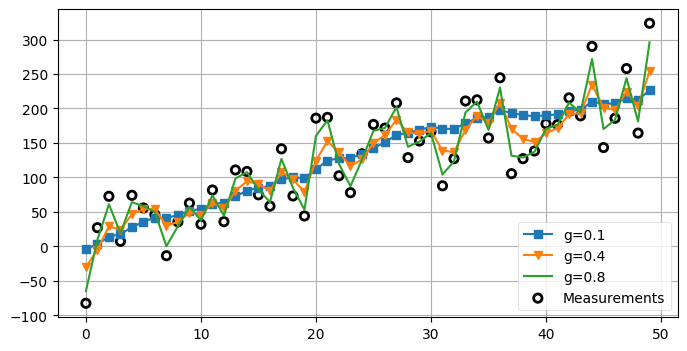

In [ ]:
np.random.seed(100)
zs = gen_data(x0=5., dx=5., count=50, noise_factor=50)
data1 = g_h_filter(data=zs, x0=0., dx=5., dt=1., g=0.1, h=0.01)
data2 = g_h_filter(data=zs, x0=0., dx=5., dt=1., g=0.4, h=0.01)
data3 = g_h_filter(data=zs, x0=0., dx=5., dt=1., g=0.8, h=0.01)

with book_plots.figsize(y=4):
    book_plots.plot_measurements(zs, color='k')
    book_plots.plot_filter(data1, label='g=0.1', marker='s', c='C0')
    book_plots.plot_filter(data2, label='g=0.4', marker='v', c='C1')
    book_plots.plot_filter(data3, label='g=0.8', c='C2')
    plt.legend(loc=4)

从图上可以很明显地看出，随着$g$地增大，我们对状态的估计越接近测量值而不是预测值。当$g = 0.8$时，估计值几乎完全跟随信号，并且几乎没有拒绝任何噪声。可能有人会天真地断定$g$应该越小越好，以最大化对噪声抑制。然而，这意味着我们将忽略很多有利于我们预测的测量值。如果信号的变化不是由于噪声而是由于实际的状态发生了变化时，会怎么样？我们来看一下。将前9个时间步长速度设为1 $\dot{x}=1$，之后的设为0 $\dot{x}=0$。

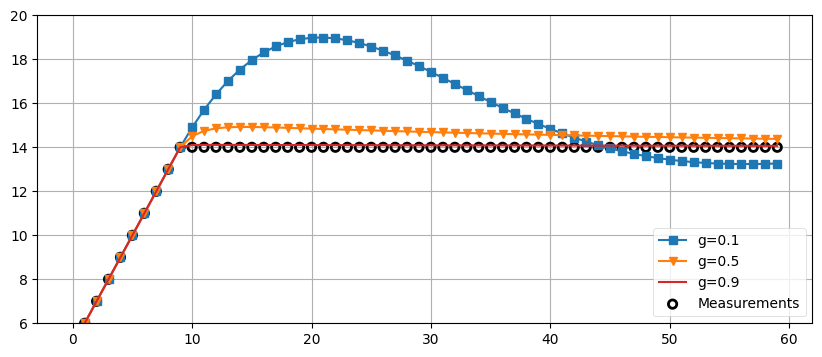

In [ ]:
zs = [5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
for i in range(50):
    zs.append(14)

data1 = g_h_filter(data=zs, x0=4., dx=1., dt=1., g=0.1, h=0.01)
data2 = g_h_filter(data=zs, x0=4., dx=1., dt=1., g=0.5, h=0.01)
data3 = g_h_filter(data=zs, x0=4., dx=1., dt=1., g=0.9, h=0.01)

book_plots.plot_measurements(zs)
book_plots.plot_filter(data1, label='g=0.1', marker='s', c='C0')
book_plots.plot_filter(data2, label='g=0.5', marker='v', c='C1')
book_plots.plot_filter(data3, label='g=0.9', c='C3')
plt.legend(loc=4)
plt.ylim([6, 20]);

在图上我们可以看到估计值忽略了本身信号的影响。我们不仅滤除了噪音，还滤除了信号的合理变化。

也许我们需要一个'金发姑娘'滤波器，其中$g$不能太大，也不能太小，而是恰到好处？好吧，其实不完全需要这样。如前所述，不同的滤波器根据问题的数学属性以不同的方式选择$g$和$h$。例如，发明出Benedict-Bordner滤波器是为了最小化瞬态误差，就像在这个例子中，速度$\dot{x}$ 发生了跳变。我们不会在本书中讨论这个过滤器，下面有两对不同$g$和$h$的效果图。这样设计出滤波器可以最大限度地减少速度$\dot{x}$ 跳变造成跳跃的瞬态误差，但代价是不适用于速度$\dot{x}$ 其他类型的变化。
> 金发姑娘是童话故事《金发姑娘和三只熊》中满头金发、口味挑剔、偷喝了粥的女主人公，她要求入口的粥不凉不烫刚刚好。

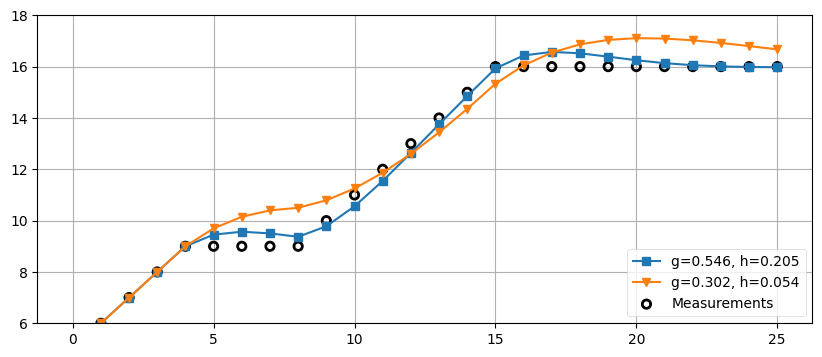

In [ ]:
zs = [5,6,7,8,9,9,9,9,9,10,11,12,13,14,
      15,16,16,16,16,16,16,16,16,16,16,16]
data1 = g_h_filter(data=zs, x0=4., dx=1., dt=1., g=.302, h=.054)
data2 = g_h_filter(data=zs, x0=4., dx=1., dt=1., g=.546, h=.205)

book_plots.plot_measurements(zs)
book_plots.plot_filter(data2, label='g=0.546, h=0.205', marker='s', c='C0')
book_plots.plot_filter(data1, label='g=0.302, h=0.054', marker='v', c='C1')
plt.legend(loc=4)
plt.ylim([6, 18]);

## 改变因子 $h$

现在让我们保持$g$不变来研究修改h会有怎样的效果。我们知道h取决于我们认为测量的$\dot{x}$对预测值的影响程度。但是，这意味着什么呢？如果我们的信号变化很大（相对于滤波器的时间步长），那么较大的h值将使滤波器迅速对这些瞬态变化作出反应。较小的$h$值则会让滤波器对变化反应地很慢。

我们来观察三个例子。我们有一个无噪音的50个步长的测量值，缓慢地从0变为1。第一个滤波器使用几乎正确的初始值$\dot{x}$和一个较小$h$值。您可以从结果中看到滤波器的输出非常接近信号。第二个过滤器使用不正确的初始值$\dot{x}=2$的。在这里，我们看到过滤器出现“ringing”，直到它稳定下来并找到信号。第三个过滤器使用相同的条件，但它的$h=0.5$。观察“ring”的幅度，你会发现它比第二张图中的小得多，但频率更高。它也比第二个过滤器更快一点稳定，但不没有提前很早。

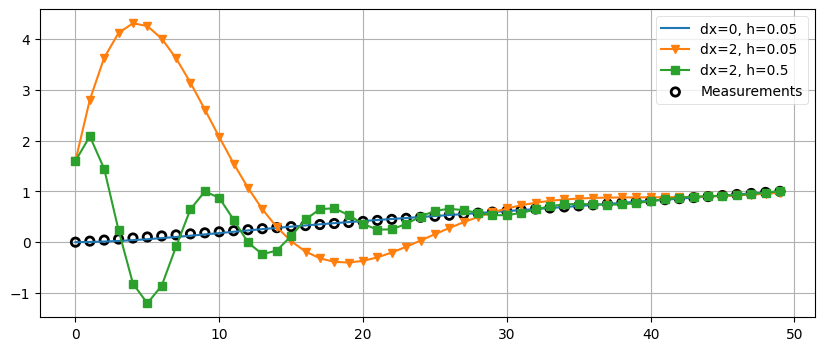

In [ ]:
zs = np.linspace(0, 1, 50)

data1 = g_h_filter(data=zs, x0=0, dx=0., dt=1., g=.2, h=0.05)
data2 = g_h_filter(data=zs, x0=0, dx=2., dt=1., g=.2, h=0.05)
data3 = g_h_filter(data=zs, x0=0, dx=2., dt=1., g=.2, h=0.5)

book_plots.plot_measurements(zs)
book_plots.plot_filter(data1, label='dx=0, h=0.05', c='C0')
book_plots.plot_filter(data2, label='dx=2, h=0.05', marker='v', c='C1')
book_plots.plot_filter(data3, label='dx=2, h=0.5',  marker='s', c='C2')
plt.legend(loc=1);

## 交互示例

对于那些在Jupyter Notebook中运行代码的人，我编写了一个滤波器的交互式版本，这样你就可以看到实时更改$\dot {x} $，$g$和$h$所产生的效果。在您调整$\dot {x}$，$g$和$h$的滑块时，数据将被重新过滤并为您绘制结果。

如果您想测试自己，请尝试在移动滑块之前先阅读下一段并预测结果。

要尝试下面的这些操作，包括将$g$和$h$设置为最小值。看看滤波器跟踪数据的完美程度！其实这只是因为我们完美预测了体重是在增加。将$ \dot {x} $调整为大于5或小于5。滤波器应该偏离数据并且永远不会重新追踪到它。这时开始增加$g$或$h$并查看滤波器是如何快速追踪到数据的。当你单独增加$g$和$h$时，看看估计的曲线有什么区别。你能解释一下差异的原因吗？然后尝试将$g$设置为大于1。您能解释一下结果吗？将$g$恢复到合理的值（例如0.1），然后将$h$的值设的非常大。 你能解释一下这些结果吗？最后，将$g$和$h$置为最大值。

如果你想探索更多的情景，可以将数组`zs`的值更改为上面任何一个图表中使用的值，然后重新运行单元格以查看结果。

In [ ]:
from ipywidgets import interact

# my FloatSlider returns an ipywidgets.FloatSlider with
# continuous_update=False. Filtering code runs too slowly
# to instantly react to slider changes.
from kf_book.book_plots import FloatSlider

zs1 = gen_data(x0=5, dx=5., count=100, noise_factor=50)

fig = None
def interactive_gh(x, dx, g, h):
    global fig
    if fig is not None: plt.close(fig)
    fig = plt.figure()
    data = g_h_filter(data=zs1, x0=x, dx=dx, g=g, h=h)
    plt.scatter(range(len(zs1)), zs1, edgecolor='k', 
                facecolors='none', marker='o', lw=1)
    plt.plot(data, color='b')

interact(interactive_gh,           
         x=FloatSlider(value=0, min=-200, max=200), 
         dx=FloatSlider(value=5, min=-50, max=50), 
         g=FloatSlider(value=.1, min=.01, max=2, step=.02), 
         h=FloatSlider(value=.02, min=.0, max=.5, step=.01));

interactive(children=(FloatSlider(value=0.0, continuous_update=False, description='x', max=200.0, min=-200.0),…

## 不要对滤波器说谎

您可以将$g$和$h$设置为任意值。下面是一个尽管存在极端噪音仍能完美运行的滤波器。

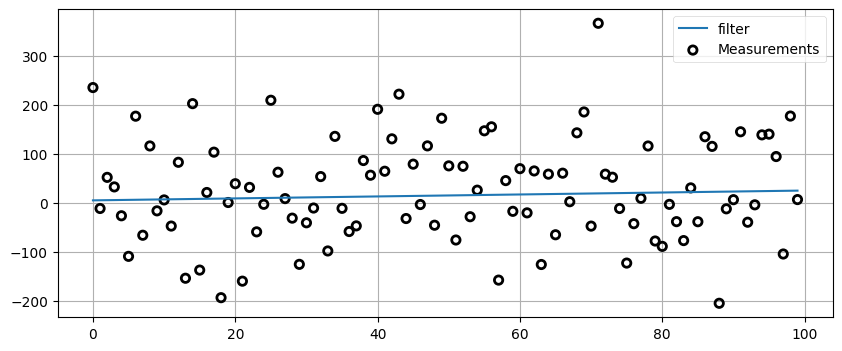

In [ ]:
zs = gen_data(x0=5., dx=.2, count=100, noise_factor=100)
data = g_h_filter(data=zs, x0=5., dx=.2, dt=1., g=0., h=0.)

book_plots.plot_measurements(zs)
book_plots.plot_filter(data, label='filter')
plt.legend(loc=1);

我从非常嘈杂的数据中完美地提取出了一条直线！也许我应该被数学领域著名的菲尔兹奖提名。我是通过将$g$和$h$设置为0才获得这样的结果。为什么这样就可以了呢？因为它使滤波器每次更新估计值时完全忽略了测量值，它只需要根据$ x + \Delta x \Delta t $计算新的位置就可以了。所以，当我们忽略测量结果时，结果当然就是一条直线了。

忽略测量值的滤波器没有实际意义。我知道你永远不会把$g$和$h$都设置为零，但我可以肯定如果你会不小心你将它们设置得低于应有的水平。那样您将始终从测试数据中获得看似完美的结果。当您尝试对其他数据进行滤波时，您会对结果感到失望，因为您对特定的数据集做了精准的调整。$g$和$h$的值必须反映您正在过滤的系统的实际行为，而不是针对一个特定数据集的行为。在后面的章节中，我们将进一步学习如何做到这一点。现在我只能说要谨慎设置，否则你的测试数据会得到完美的结果，但是一旦切换到真实数据就会得到下面的结果：

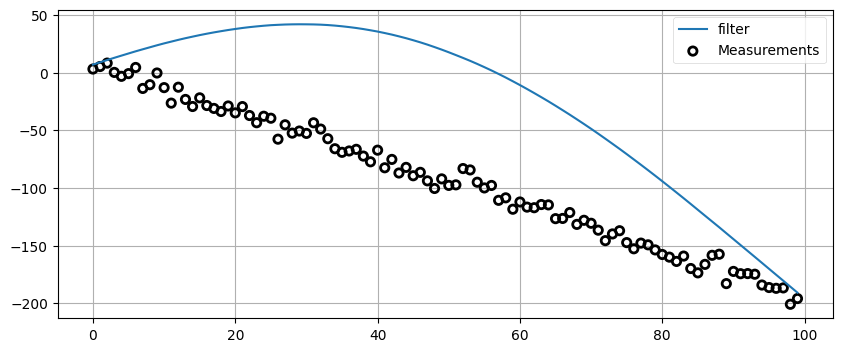

In [ ]:
zs = gen_data(x0=5, dx=-2, count=100, noise_factor=5)
data = g_h_filter(data=zs, x0=5., dx=2., dt=1., g=.005, h=0.001)
book_plots.plot_measurements(zs)
book_plots.plot_filter(data, label='filter')
plt.legend(loc=1);

## 跟踪火车

我们已经准备尝试一个实际的例子了。还记得在本章的前面，我们讨论了跟踪火车的问题。火车很重，也很慢，它无法快速改变速度。火车行驶在轨道上，所以他们不能改变方向，除非通过减速停止然后逆转方向。因此，如果我们已知火车的近似的位置和速度，那么我们可以准确地预测它在未来很短的时间内的位置。火车不能在一两秒内改变它的速度。

那么让我们为火车来写一个滤波器。火车的位置是指为它在轨道上相对于某个在0km 的固定点的距离。 即，在1这个位置意味着火车距离固定点1公里。 速度表示为米/秒。我们每秒测量一次位置，误差是$\pm$500米。 我们该如何设计我们的滤波器呢？

首先，让我们先模拟没有滤波器的情况。我们假设火车目前在23公里处，并以15米/秒的速度移动。我们可以将其编码为：

```python
pos = 23*1000
vel = 15
```

假设速度没有变化，那么我们可以计算出未来某个时间列车的位置：

```python
def compute_new_position(pos, vel, dt=1):
   return pos + (vel * dt)
```

然后我们向位置信息添加一些随机噪声来模拟测量值。这里我们测量的误差是500米，所以代码如下所示：

```python
def measure_position(pos):
   return pos + random.randn()*500
```
        
我们把这些整合起来，并绘制出100秒内的模拟的测量值。我将使用NumPy的`asarray`函数将数据转换为NumPy数组。这样我就可以用'/'一次性对所有的数据元素进除法运算。

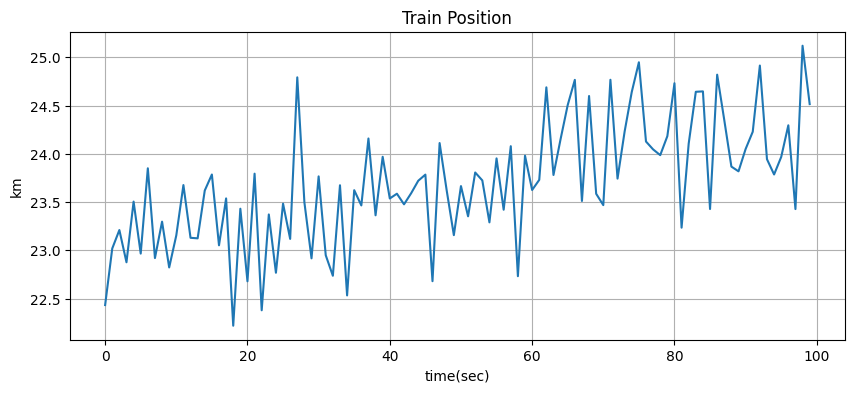

In [ ]:
from numpy.random import randn

def compute_new_position(pos, vel, dt=1.):
    """ dt is the time delta in seconds."""
    return pos + (vel * dt)

def measure_position(pos):
    return pos + randn()*500

def gen_train_data(pos, vel, count):
    zs = []
    for t in range(count):
        pos = compute_new_position(pos, vel)
        zs.append(measure_position(pos))
    return np.asarray(zs)
  
pos, vel = 23.*1000, 15.
zs = gen_train_data(pos, vel, 100)

plt.plot(zs / 1000.)  # convert to km
book_plots.set_labels('Train Position', 'time(sec)', 'km')

从图表中我们可以看出测量的结果十分糟糕。真正的火车是不可能这样移动的。 

那么如果我们想要过滤这些数据，我们应该怎样设置$g$和$h$？我们还没有足够的理论支撑，但让我们先试着凭感觉给个合理的答案。我们现在知道测量结果非常不准确，所以我们不想给它们太多的权重。要做到这一点，我们需要选择一个非常小的$g$。我们也知道火车不能快速地加速或减速，所以我们把$h$也设置为一个很小的值。 例如：

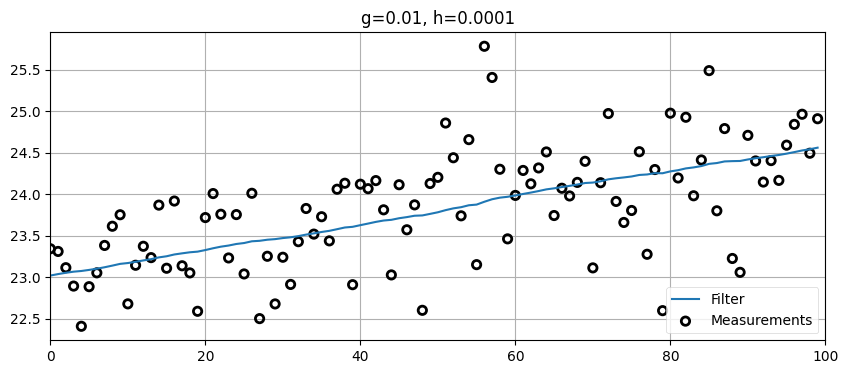

In [ ]:
zs = gen_train_data(pos=pos, vel=15., count=100)
data = g_h_filter(data=zs, x0=pos, dx=15., dt=1., g=.01, h=0.0001)
plot_g_h_results(zs/1000., data/1000., 'g=0.01, h=0.0001')

对于初步尝试来说结果看起来很不错，我们把$g$调大一些，看看会有怎样的效果。

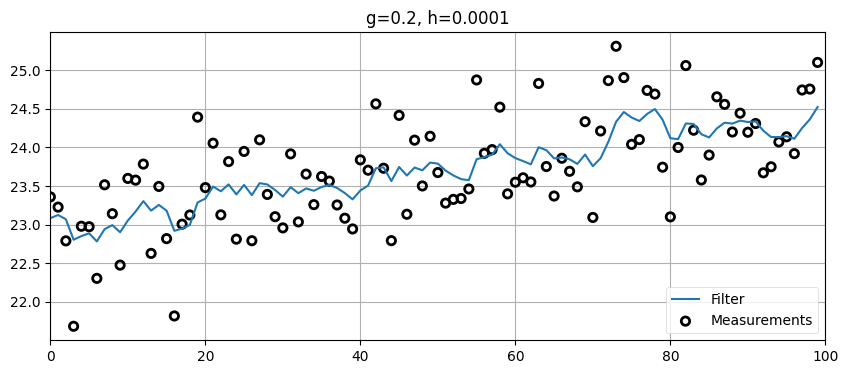

In [ ]:
zs = gen_train_data(pos=pos, vel=15., count=100)
data = g_h_filter(data=zs, x0=pos, dx=15., dt=1., g=.2, h=0.0001)
plot_g_h_results(zs/1000., data/1000., 'g=0.2, h=0.0001')

当`g=0.2`时，我们可以看到，尽管火车的位置应该是平滑变化的，估计的位置（包括速度）在非常短的时间内波动很大，真正的火车是不可能做到的。所以我们的`g << 0.2`。

我们再看看$h$选择不当会带来的影响。

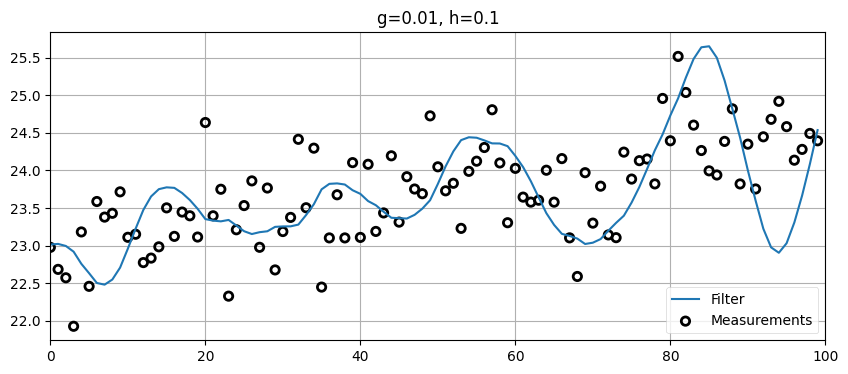

In [ ]:
zs = gen_train_data(pos=pos, vel=15., count=100)
data = g_h_filter(data=zs, x0=pos, dx=15., dt=1., g=0.01, h=0.1)
plot_g_h_results(zs/1000., data/1000., 'g=0.01, h=0.1')

由于$g$很小，火车位置变化得很平稳，但是较大的$h$值使得滤波器对测量值非常敏感。发生这种情况是因为在几秒钟内位置测量值快速的变化意味着速度也发生了很大的变化，较大的$h$值告诉滤波器需要快速响应这些变化。但是火车不能快速改变速度，然而这样的滤波器比火车还快地改变了速度，因此这个滤波器不能很好地过滤数据。

最后，我们为火车增加一些加速度。我不知道列车实际的加速度有多少，但我们可以设它的加速度为0.2米/秒^ 2。

In [ ]:
def gen_train_data_with_acc(pos, vel, count):
    zs = []
    for t in range(count):
        pos = compute_new_position(pos, vel)
        vel += 0.2
        zs.append(measure_position(pos))
    return np.asarray(zs) 

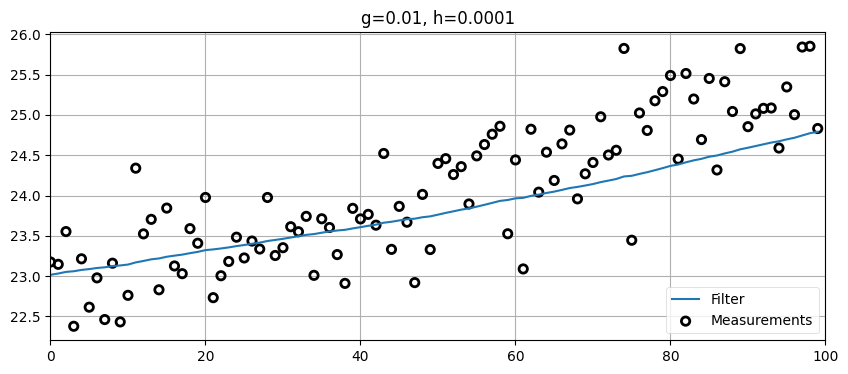

In [ ]:
zs = gen_train_data_with_acc(pos=pos, vel=15., count=100)
data = g_h_filter(data=zs, x0=pos, dx=15., dt=1., g=.01, h=0.0001)
plot_g_h_results(zs/1000., data/1000., 'g=0.01, h=0.0001')

从图上我们可以看到由于加速的原因而滤波器无法再定位列车的位置了。 我们可以修改$h$以让它更好地跟踪，但代价是不太平滑的滤波估计。

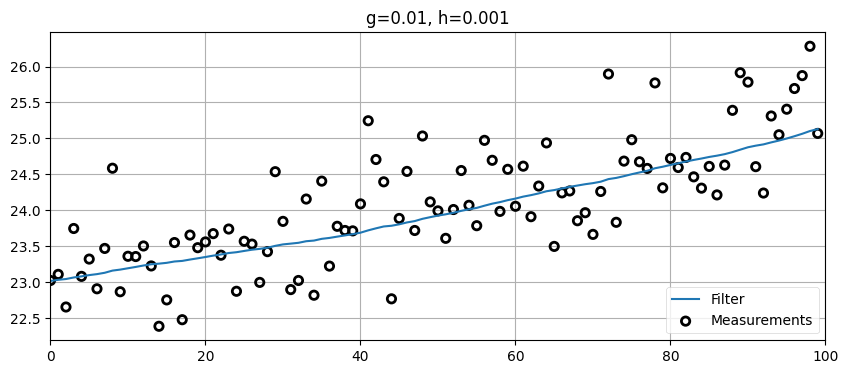

In [ ]:
zs = gen_train_data_with_acc(pos=pos, vel=15., count=100)
data = g_h_filter(data=zs, x0=pos, dx=15., dt=1., g=.01, h=0.001)
plot_g_h_results(zs/1000., data/1000., 'g=0.01, h=0.001')

这里有两点可以吸取的教训。首先，使用h值来响应您待建模的速度变化。 但是，更重要的是，在系统处于稳定状态时，你需要在快速准确地响应行为变化和产生理想的输出之间需要进行权衡。如果火车永远不会改变速度，我们可以把$h$设得极小，以避免过滤后的估计值过度受到测量噪声的影响。但是在一个真实的问题中，状态几乎总会发生变化，我们希望快速对它们做出反应。我们对此反应的越快，我们受传感器噪声的影响就越大。

我可以继续讲下去，但我的目标不是在这里研究g-h滤波器理论，以便深入了解综合测量值和预测值的滤波方案。关于解决如何选择$g$和$h$的文献很多，并且有最佳方法可以选择它们来实现各种目标。正如我之前解释的那样，在试验这样的测试数据时很容易对滤波器“撒谎”。在随后的章节中，我们将学习卡尔曼滤波器如何以相同的基本但更复杂的数学方式解决这个问题。 

## 基于 FilterPy 实现 g-h 滤波器

[FilterPy](https://github.com/rlabbe/filterpy)是我写的一个开源的滤波器库。拥有本书中的所有过滤器以及其他过滤器。编程自己的g-h过滤器相当容易，但随着我们的进步，我们将更多地依赖FilterPy。简单介绍一下FilterPy中的g-h过滤器。

如果你还没有安装FilterPy，只需在命令行中使用以下命令。

    pip install filterpy

有关从GitHub安装或下载FilterPy的更多信息，请参阅附录A。

要使用g-h过滤器，导入它并从类`GHFilter`实例化对象。

In [ ]:
from filterpy.gh import GHFilter
f = GHFilter(x=0., dx=0., dt=1., g=.8, h=.2)

构造对象时，需要指定信号的初始值和变化率（`x`和`dx`）、更新之间的时间步长（`dt`）和两个滤波器器参数（`g`和`h`）。`dx`必须和`x`/`dt`有相同的单位——如果`x`以米为单位，而`dt`以秒为单位，那么`dx`的单位必须是米每秒。

要运行滤波器，调用`update()`，并在在参数`z`中传递测量值，您会记得这是文献中度量值的标准名称。

In [ ]:
f.update(z=1.2)

(0.96, 0.24)

`update()`以元组的形式返回`x`和`dx`的新值，你也可以从对象访问它们。

In [ ]:
print(f.x, f.dx)

0.96 0.24


你可以动态更改 `g` and `h`.

In [ ]:
print(f.update(z=2.1, g=.85, h=.15))

(1.965, 0.375)


你可以批量滤波测量序列。

In [ ]:
print(f.batch_filter([3., 4., 5.]))

[[1.965 0.375]
 [2.868 0.507]
 [3.875 0.632]
 [4.901 0.731]]


你可以过滤多个自变量。如果你正在跟踪一架飞机，你需要在3D空间中跟踪它。对`x`、`dx`和测量值使用NumPy数组。

In [ ]:
x_0  = np.array([1., 10., 100.])
dx_0 = np.array([10., 12., .2])
               
f_air = GHFilter(x=x_0, dx=dx_0, dt=1., g=.8, h=.2)
f_air.update(z=np.array((2., 11., 102.)))
print(' x =', f_air.x)
print('dx =', f_air.dx)

 x = [  3.8   13.2  101.64]
dx = [8.2  9.8  0.56]


类`GHFilterOrder`允许你创建一个0阶、1阶或2阶的过滤器。g-h过滤器是1阶的。我们还没有谈到的g-h-k滤波器也跟踪加速度。这两个类都具有实际应用程序所需的功能，例如计算方差缩减因子（Variance Reduction Factor，VRF），这一点我们在本章中没有讨论。我可以写一本关于g-h滤波器的理论和应用的书，但我们在这本书中还有其他目标。如果您感兴趣，请浏览FilterPy代码并进一步阅读。

FilterPy的文档位于：https://filterpy.readthedocs.org/。

## 总结

我鼓励你尝试通过实验滤波器来理解它是怎么工作的。不应该花太多时间去关注一些表现不佳的$g$和$h$特例。一种特殊的选择可能在一种情况下表现良好，但在另一种情况下表现很差。即使你理解了$g$和$h$的作用，也很难选择合适的值。事实上，你不太可能选择一对对任何问题都是最佳的$g$和$h$的值。过滤器是被*设计*出来的，而不是*特别制定*的。

从某些方面讲，我不想在这里结束这一章，因为我们关于如何选择$g$和$h$还有许多可以讲的内容。但是以这种形式介绍g-h滤波器不是本书的目的。设计卡尔曼滤波器需要你指定一些参数——它们间接地与如何选择$g$和$h$有关，但在设计卡尔曼滤波器时你永远不会直接用到它们。此外，$g$和$h$还将在每一个时间点都以一种非常不明显的方式变化。

还有滤波器的另一个特征我们还没有涉及——贝叶斯统计。您可能注意到“贝叶斯”一词出现在本书的标题中; 这不是巧合！现在，让我们先放下$g$和$h$其他未深入理解的知识，来研究一种可以高效的用于滤波的概率推理形式。我们会遇到一个类似g-h滤波器的算法。这次我们将使用了正式的数学模型，允许我们根据多个传感器创建滤波器，准确估计解决方案中的误差，并控制机器人。